# K05_02 – Logistische Regression: Lernerfolg klassifizieren

Update am 24. Mai 2026

## Lernziele
- einen kleinen Klassifikationsdatensatz verstehen
- logistische Regression trainieren
- Wahrscheinlichkeiten für neue Fälle interpretieren
- Konfusionsmatrix, Precision, Recall und F1 anwenden

## 1. Bibliotheken importieren

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)

## 2. Beispieldaten erzeugen

Wir verwenden einen kleinen fiktiven Datensatz mit zwei Merkmalen:

- `lernzeit`: Stunden pro Woche
- `anwesenheit`: Anwesenheitsquote in Prozent

Zielvariable:
- `1` = bestanden
- `0` = nicht bestanden

In [ ]:
np.random.seed(42)

n_samples = 120

lernzeit = np.random.uniform(0, 20, n_samples)
anwesenheit = np.random.uniform(40, 100, n_samples)

# künstliche, aber plausible Regel mit Zufallseinfluss
score = 0.25 * lernzeit + 0.06 * anwesenheit - 5.5 + np.random.normal(0, 0.7, n_samples)
y = (score > 0).astype(int)

X = np.column_stack([lernzeit, anwesenheit])

print("Shape von X:", X.shape)
print("Shape von y:", y.shape)
print("Anzahl Klasse 0:", np.sum(y == 0))
print("Anzahl Klasse 1:", np.sum(y == 1))

Shape von X: (120, 2)
Shape von y: (120,)
Anzahl Klasse 0: 36
Anzahl Klasse 1: 84


## 3. Daten visualisieren

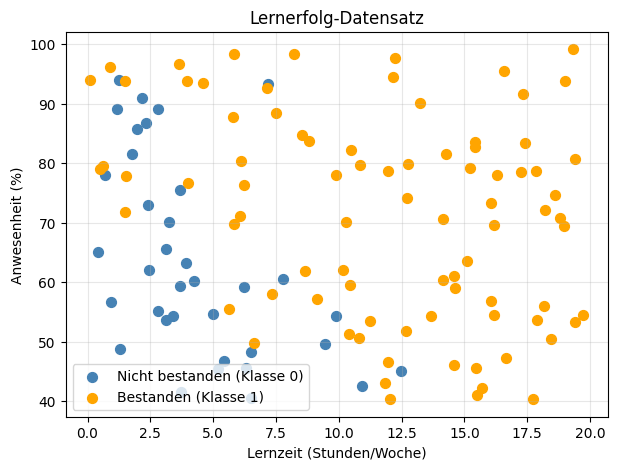

In [ ]:
# Zwei separate scatter()-Aufrufe fuer eine saubere Legende
plt.figure(figsize=(7, 5))
plt.scatter(
    X[y == 0, 0], X[y == 0, 1],
    color='steelblue', s=50, label='Nicht bestanden (Klasse 0)'
)
plt.scatter(
    X[y == 1, 0], X[y == 1, 1],
    color='orange', s=50, label='Bestanden (Klasse 1)'
)
plt.xlabel("Lernzeit (Stunden/Woche)")
plt.ylabel("Anwesenheit (%)")
plt.title("Lernerfolg-Datensatz")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 4. Trainings- und Testdaten erzeugen

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Trainingsdaten:", X_train.shape, y_train.shape)
print("Testdaten     :", X_test.shape, y_test.shape)

Trainingsdaten: (84, 2) (84,)
Testdaten     : (36, 2) (36,)


## 5. Modell trainieren

In [ ]:
clf = LogisticRegression(
    max_iter=1000   # erhoehe Standardwert (100), damit der Optimierer sicher konvergiert
                    # bei gut skalierten Daten oft nicht noetig, hier zur Sicherheit
)
clf.fit(X_train, y_train)

print("Modell trainiert.")
print(f"Koeffizienten: Lernzeit={clf.coef_[0,0]:.3f}, Anwesenheit={clf.coef_[0,1]:.3f}")
print(f"Intercept: {clf.intercept_[0]:.3f}")


Modell trainiert.
Koeffizienten: Lernzeit=0.616, Anwesenheit=0.110
Intercept: -10.447


## 6. Vorhersagen und Metriken

Accuracy : 0.806
Precision: 0.800
Recall   : 0.960
F1-Score : 0.873


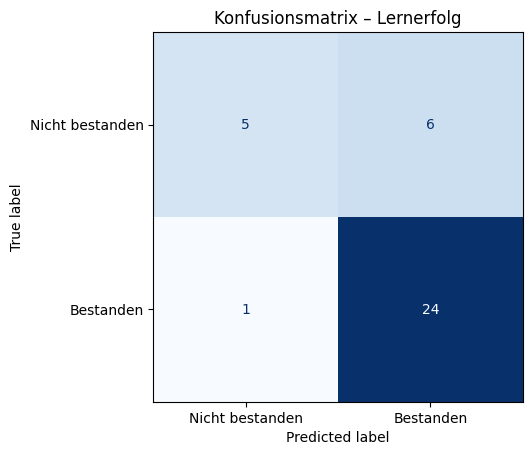

In [ ]:
y_pred = clf.predict(X_test)

acc       = accuracy_score(y_test, y_pred)
cm        = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print(f"Accuracy : {acc:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1-Score : {f1:.3f}")

# Konfusionsmatrix als beschriftete Grafik
# Zeilen = wahre Klasse | Spalten = vorhergesagte Klasse
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Nicht bestanden", "Bestanden"]
)
disp.plot(cmap="Blues", colorbar=False, values_format="d")
plt.title("Konfusionsmatrix – Lernerfolg")
plt.show()


## 7. Wahrscheinlichkeiten für neue Fälle

In [ ]:
neue_faelle = np.array([
    [4, 55],
    [10, 80],
    [15, 92]
])

proba = clf.predict_proba(neue_faelle)[:, 1]
pred = clf.predict(neue_faelle)

for fall, p, c in zip(neue_faelle, proba, pred):
    print(f"Lernzeit={fall[0]:>2}, Anwesenheit={fall[1]:>2} -> P(bestanden)={p:.3f}, Vorhersage={c}")

Lernzeit= 4, Anwesenheit=55 -> P(bestanden)=0.127, Vorhersage=0
Lernzeit=10, Anwesenheit=80 -> P(bestanden)=0.989, Vorhersage=1
Lernzeit=15, Anwesenheit=92 -> P(bestanden)=1.000, Vorhersage=1


## Schwellwert-Anpassung

Der Standard-Schwellwert 0.5 kann angepasst werden.

**Frage fuer diesen Kontext:** Ist es schlimmer, einen Studierenden
faelschlicherweise als *nicht bestanden* einzustufen (FN),
oder ihn faelschlicherweise als *bestanden* einzustufen (FP)?

> Wenn FN problematischer ist (übersehene Förderbedarfe) → **Schwellwert senken → Recall steigt**

Das koennen wir mit `predict_proba()` direkt steuern:


In [ ]:
# Wahrscheinlichkeiten fuer alle Testpunkte
proba_test = clf.predict_proba(X_test)[:, 1]   # P(bestanden)

print(f"{'Schwellwert':>12} | {'Precision':>10} | {'Recall':>8} | {'F1':>8}")
print("-" * 48)

for sw in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_sw = (proba_test >= sw).astype(int)
    if len(set(y_sw)) > 1:   # beide Klassen muessen vorkommen
        p = precision_score(y_test, y_sw)
        r = recall_score(y_test, y_sw)
        f = f1_score(y_test, y_sw)
        marker = "  <- Standard" if sw == 0.5 else ""
        print(f"{sw:>12.1f} | {p:>10.3f} | {r:>8.3f} | {f:>8.3f}{marker}")
    else:
        print(f"{sw:>12.1f} | nur eine Klasse vorhergesagt")


 Schwellwert |  Precision |   Recall |       F1
------------------------------------------------
         0.3 |      0.774 |    0.960 |    0.857
         0.4 |      0.774 |    0.960 |    0.857
         0.5 |      0.800 |    0.960 |    0.873  <- Standard
         0.6 |      0.828 |    0.960 |    0.889
         0.7 |      0.852 |    0.920 |    0.885


## 8. Kleine Übung

**Aufgabe 1:**  
Interpretieren Sie die Konfusionsmatrix in Worten.

**Aufgabe 2:**  
Welcher neue Fall erscheint Ihnen besonders sicher? Welcher eher grenzwertig?

**Aufgabe 3:**  
Ändern Sie einen der drei neuen Fälle leicht ab und beobachten Sie, wie sich die Wahrscheinlichkeit verändert.

## 8. Kleine Übung – Musterlösung

In [ ]:
eigener_fall = np.array([[8, 70]])
eigene_proba = clf.predict_proba(eigener_fall)[:, 1][0]
eigene_pred = clf.predict(eigener_fall)[0]

print(f"Eigener Fall {eigener_fall.tolist()[0]} -> P(bestanden)={eigene_proba:.3f}, Vorhersage={eigene_pred}")

Eigener Fall [8, 70] -> P(bestanden)=0.899, Vorhersage=1


### Musterantworten

**Konfusionsmatrix in Worten – mit TP/FP/FN/TN:**

```
                     Vorhergesagt:
                   Nicht bestanden | Bestanden
Tatsaechlich: Nicht bestanden  TN  |    FP
              Bestanden        FN  |    TP
```

- **TN (True Negative):** Korrekt als nicht bestanden erkannt
- **TP (True Positive):** Korrekt als bestanden erkannt
- **FP (False Positive):** Als bestanden vorhergesagt, tatsaechlich nicht bestanden
  *(falscher Alarm – ein Studierender wird zu Unrecht als erfolgreich eingestuft)*
- **FN (False Negative):** Als nicht bestanden vorhergesagt, tatsaechlich bestanden
  *(verpasster Erfolg – ein Studierender wird zu Unrecht als nicht erfolgreich eingestuft)*

**Welcher Fall erscheint besonders sicher?**
In der Regel der Fall mit hoher Lernzeit und hoher Anwesenheit.
Die vorhergesagte Wahrscheinlichkeit liegt dann deutlich ueber 0.5.

**Welcher Fall ist grenzwertig?**
Ein Fall nahe der Entscheidungsgrenze – Wahrscheinlichkeit ~0.5.
Kleine Aenderungen der Eingabe koennen die Vorhersage kippen.

## Didaktischer Hinweis
Dieses Notebook eignet sich sehr gut als Uebungs- und Transfernotebook, weil Studierende:
- die Metriken anwenden,
- Wahrscheinlichkeiten inhaltlich deuten,
- und einen lebensnahen Kontext haben.


## 9. Visualisierung der Entscheidungsgrenze und Wahrscheinlichkeiten

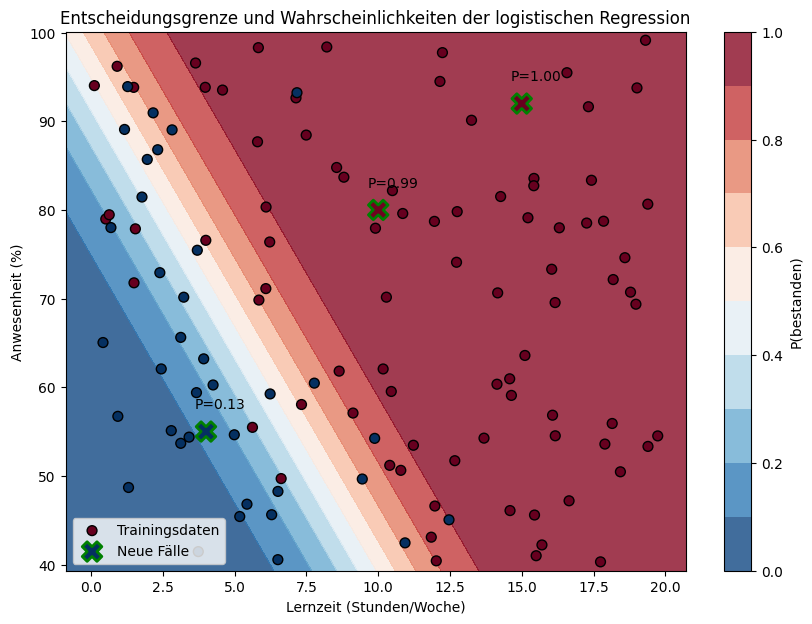

In [ ]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdBu_r, levels=np.linspace(0, 1, 11))
plt.colorbar(label='P(bestanden)')
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, edgecolors='k', cmap=plt.cm.RdBu_r, label='Trainingsdaten')

plt.scatter(neue_faelle[:, 0], neue_faelle[:, 1], c=proba,
            marker='X', s=200, edgecolors='green', linewidth=2,
            cmap=plt.cm.RdBu_r, label='Neue Fälle')

for i, (fall, p, c) in enumerate(zip(neue_faelle, proba, pred)):
    plt.annotate(f'P={p:.2f}', (fall[0] + 0.5, fall[1] + 1),
                 textcoords="offset points", xytext=(0,10), ha='center', color='black', fontsize=10)

plt.xlabel("Lernzeit (Stunden/Woche)")
plt.ylabel("Anwesenheit (%)")
plt.title("Entscheidungsgrenze und Wahrscheinlichkeiten der logistischen Regression")
plt.legend()
plt.show()

## 10. Reflexion
- Worin unterscheiden sich Accuracy und F1-Score?
- Wann wäre Recall wichtiger als Precision?

## Reflexion – Erläuterung für Studierende

---

### Worin unterscheiden sich Accuracy und F1-Score?

**Accuracy** zählt einfach, wie viele Vorhersagen insgesamt richtig waren:

```
Accuracy = Richtige Vorhersagen / Alle Vorhersagen
```

Das klingt intuitiv, hat aber ein großes Problem bei **unbalancierten Datensätzen**:

```
Datensatz: 950× Klasse 0,  50× Klasse 1
Modell sagt immer "Klasse 0" → Accuracy = 95%  ← klingt super, ist wertlos
```

Der **F1-Score** kombiniert zwei differenziertere Maße — Precision und Recall:

```
Precision = Von allen "Klasse 1"-Vorhersagen: wie viele waren wirklich Klasse 1?
Recall    = Von allen echten "Klasse 1"-Fällen: wie viele hat das Modell gefunden?

F1 = 2 × (Precision × Recall) / (Precision + Recall)
```

Ein Modell, das immer „Klasse 0" sagt, hat einen **Recall von 0** für Klasse 1 — der F1-Score bricht sofort ein und entlarvt das schlechte Modell.

> **Merksatz:** Accuracy lügt bei unbalancierten Daten. Der F1-Score nicht.

---

### Wann wäre Recall wichtiger als Precision?

Es kommt auf die **Kosten eines Fehlers** an. Es gibt zwei Fehlertypen:

```
False Negative (FN): Modell sagt "kein Krebs"  → Patient hat aber Krebs   ← gefährlich
False Positive (FP): Modell sagt "Krebs"       → Patient hat keinen Krebs  ← unnötiger Stress
```

**Recall** minimiert False Negatives — man findet möglichst alle echten Fälle.
**Precision** minimiert False Positives — man macht möglichst wenig falsche Alarme.

| Anwendung | Wichtiger | Warum |
|---|---|---|
| Krebsdiagnose | **Recall** | Einen kranken Patienten zu übersehen ist fatal |
| Spam-Filter | **Precision** | Wichtige E-Mails als Spam zu markieren ist ärgerlich |
| Betrugserkennung (Kreditkarte) | **Recall** | Jeden Betrugsfall finden, auch auf Kosten falscher Alarme |
| Bewerbungsauswahl (KI) | **Precision** | Nur wirklich geeignete Kandidaten weiterleiten |

> **Merksatz:** Wenn ein verpasster Fall schlimmer ist als ein falscher Alarm → **Recall**. Wenn ein falscher Alarm schlimmer ist als ein verpasster Fall → **Precision**.